In [108]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from textblob import TextBlob
import plotly.express as px
import dash
from dash import dcc, html, Input, Output
import dash_bootstrap_components as dbc

In [109]:
data = pd.read_csv('amazon.csv')
data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [110]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B08WRWPM22,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [111]:
data.duplicated().sum()

np.int64(0)

In [112]:
data = data.drop(
    columns=['product_id',
             'user_id',
             'user_name',
             'review_id',
             'img_link',
             'product_link']
    )
data.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_title,review_content
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


In [113]:
data['discounted_price'] = data['discounted_price'].str.replace(r'[₹,%,,]', '', regex=True).astype(float)
data['actual_price'] = data['actual_price'].str.replace(r'[₹,%,,]', '', regex=True).astype(float)
data['discount_percentage'] = data['discount_percentage'].str.replace(r'[₹,%,,]', '', regex=True).astype(float)
data['rating_count'] = data['rating_count'].str.replace(r'[₹,%,,]', '', regex=True).astype(float)
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data['rating'] = data['rating'].fillna(data['rating'].median())


In [114]:
data['about_product'].value_counts()

about_product
[CHARGE & SYNC FUNCTION]- This cable comes with charging & Data sync function|[HIGH QUALITY MATERIAL]- TPE + Nylon Material to make sure that the life of the cable is enhanced significantly|[LONG CORD]- The Cable is extra thick 1.2 meter long, optimized for an easy use for your comfort at home or office|[MORE DURABLE]-This cable is unique interms of design and multi-use and is positioned to provide the best comfort and performance while using|[UNIVERSAL COMPATIBILITY]- Compatible with all devices like iPhone XS, X, XR, 8, 7, 6S, 6, 5S, iPad Pro, iPad mini and iPad Air                                                                                                                                                                                                                                                                                                                                                                                                                            

In [115]:
data = data.replace(r'[\[\],\-+|;:/]', '', regex=True)


In [116]:
data.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_title,review_content
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&AccessoriesAccessories&PeripheralsCa...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility Compatible With iPhone 12 ...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...
1,Ambrane Unbreakable 60W 3A Fast Charging 1.5m...,Computers&AccessoriesAccessories&PeripheralsCa...,199.0,349.0,43.0,4.0,43994.0,Compatible with all Type C enabled devices be ...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&AccessoriesAccessories&PeripheralsCa...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】With builtin safety ...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttpsm.mediaamazon...
3,boAt Deuce USB 300 2 in 1 TypeC & Micro USB St...,Computers&AccessoriesAccessories&PeripheralsCa...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&AccessoriesAccessories&PeripheralsCa...,154.0,399.0,61.0,4.2,16905.0,CHARGE & SYNC FUNCTION This cable comes with c...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...


In [117]:
data.columns

Index(['product_name', 'category', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'about_product',
       'review_title', 'review_content'],
      dtype='object')

In [118]:
data['estimated_demand'] = data['rating_count'] * data['rating']
data['revenue_score'] = data['estimated_demand'] * data['discounted_price']
data['profit_margin_given'] = data['actual_price'] - data['discounted_price']
data['profit'] = data['revenue_score'] * 0.15
data['sales'] = data['revenue_score'] * 0.85
data.dropna(inplace=True)
data.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_title,review_content,estimated_demand,revenue_score,profit_margin_given,profit,sales
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&AccessoriesAccessories&PeripheralsCa...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility Compatible With iPhone 12 ...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...,101929.8,40669990.2,700.0,6100498.53,3.456949e+07
1,Ambrane Unbreakable 60W 3A Fast Charging 1.5m...,Computers&AccessoriesAccessories&PeripheralsCa...,199.0,349.0,43.0,4.0,43994.0,Compatible with all Type C enabled devices be ...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...,175976.0,35019224.0,150.0,5252883.60,2.976634e+07
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&AccessoriesAccessories&PeripheralsCa...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】With builtin safety ...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttpsm.mediaamazon...,30919.2,6152920.8,1700.0,922938.12,5.229983e+06
3,boAt Deuce USB 300 2 in 1 TypeC & Micro USB St...,Computers&AccessoriesAccessories&PeripheralsCa...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...,396324.6,130390793.4,370.0,19558619.01,1.108322e+08
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&AccessoriesAccessories&PeripheralsCa...,154.0,399.0,61.0,4.2,16905.0,CHARGE & SYNC FUNCTION This cable comes with c...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...,71001.0,10934154.0,245.0,1640123.10,9.294031e+06


In [119]:
def final_category(x):
    x = str(x).lower()
    
    if 'cable' in x:
        return 'Cables'
    elif 'smartphone' in x:
        return 'Mobile'
    elif 'watch' in x:
        return 'Watch'
    elif 'television' in x:
        return 'TV'
    elif 'headphone' in x or 'earbud' in x:
        return 'Audio'
    elif 'heater' in x:
        return 'Heater'
    elif 'kettle' in x:
        return 'Kettle'
    elif 'mixer' in x or 'grinder' in x:
        return 'Mixer'
    elif 'charger' in x:
        return 'Charger'
    elif 'mouse' in x:
        return 'Mouse'
    elif 'keyboard' in x:
        return 'Keyboard'
    elif 'iron' in x:
        return 'Iron'
    else:
        return 'Other'

data['final_category'] = data['category'].apply(final_category)

In [120]:
data['category'] = data['category'].apply(lambda x: x.split('&')[-1])
data['category'].value_counts().head(27)
#top 10 categories
top_cat = (
    data.groupby('final_category')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_cat)

final_category
Mobile     1.052300e+11
TV         6.308753e+10
Other      3.428980e+10
Audio      1.300903e+10
Watch      1.250374e+10
Cables     6.522367e+09
Charger    4.479812e+09
Mixer      4.263518e+09
Heater     3.879704e+09
Iron       3.872173e+09
Name: sales, dtype: float64


In [121]:
data['main_category'] = data['category'].str.split('&').str[0]

In [122]:
top_categories = data.groupby('category')['revenue_score'].sum().reset_index()
revenue_by_category = top_categories.sort_values(by='revenue_score', ascending=False).head(5)
avg_rating_by_category = data.groupby('category')['rating'].mean().reset_index()


In [123]:
data.head()

,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_title,review_content,estimated_demand,revenue_score,profit_margin_given,profit,sales,final_category,main_category
0,Wayona Nylon Braided USB to Lightning Fast Cha...,AccessoriesCablesUSBCables,399.0,1099.0,64.0,4.2,24269.0,High Compatibility Compatible With iPhone 12 ...,SatisfiedCharging is really fastValue for mone...,Looks durable Charging is fine tooNo complains...,101929.8,40669990.2,700.0,6100498.53,3.456949e+07,Cables,AccessoriesCablesUSBCables
1,Ambrane Unbreakable 60W 3A Fast Charging 1.5m...,AccessoriesCablesUSBCables,199.0,349.0,43.0,4.0,43994.0,Compatible with all Type C enabled devices be ...,A Good Braided Cable for Your Type C DeviceGoo...,I ordered this cable to connect my phone to An...,175976.0,35019224.0,150.0,5252883.60,2.976634e+07,Cables,AccessoriesCablesUSBCables
2,Sounce Fast Phone Charging Cable & Data Sync U...,AccessoriesCablesUSBCables,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】With builtin safety ...,Good speed for earlier versionsGood ProductWor...,Not quite durable and sturdyhttpsm.mediaamazon...,30919.2,6152920.8,1700.0,922938.12,5.229983e+06,Cables,AccessoriesCablesUSBCables
3,boAt Deuce USB 300 2 in 1 TypeC & Micro USB St...,AccessoriesCablesUSBCables,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,Good productGood oneNiceReally nice productVer...,Good productlong wireCharges goodNiceI bought ...,396324.6,130390793.4,370.0,19558619.01,1.108322e+08,Cables,AccessoriesCablesUSBCables
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,AccessoriesCablesUSBCables,154.0,399.0,61.0,4.2,16905.0,CHARGE & SYNC FUNCTION This cable comes with c...,As good as originalDecentGood one for secondar...,Bought this instead of original apple does the...,71001.0,10934154.0,245.0,1640123.10,9.294031e+06,Cables,AccessoriesCablesUSBCables


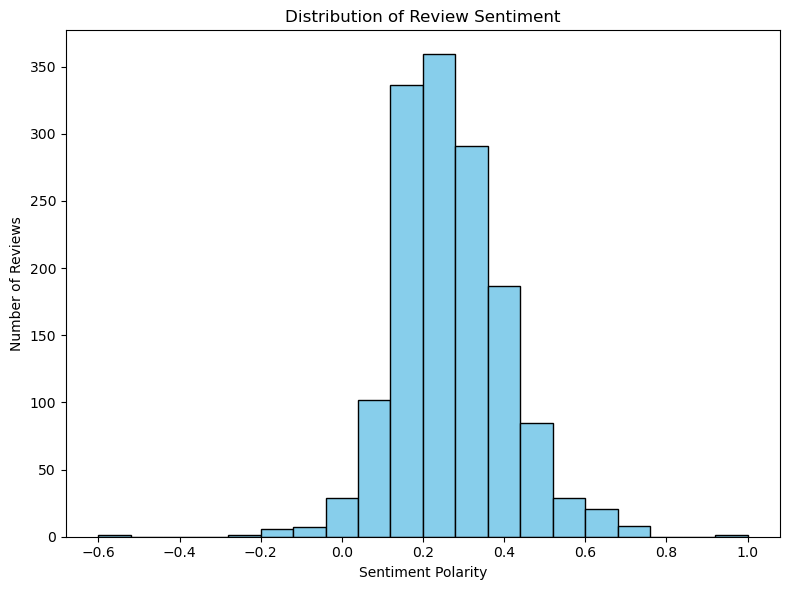

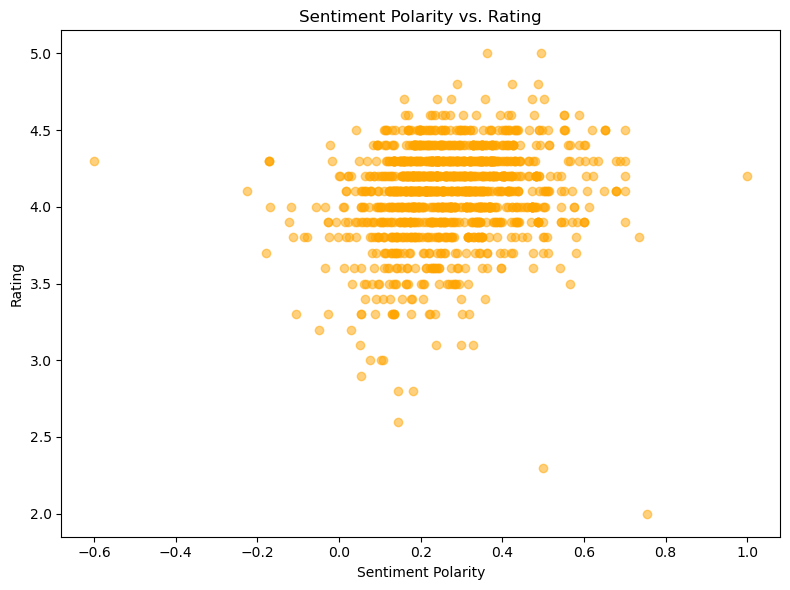

In [124]:

data['sentiment'] = data['review_content'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
# Postive vs Negative Reviews
plt.figure(figsize=(8, 6))
plt.hist(data['sentiment'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Review Sentiment')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()
# sentiment vs rating
plt.figure(figsize=(8, 6))
plt.scatter(data['sentiment'], data['rating'], alpha=0.5, color='orange')
plt.title('Sentiment Polarity vs. Rating')  
plt.xlabel('Sentiment Polarity')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

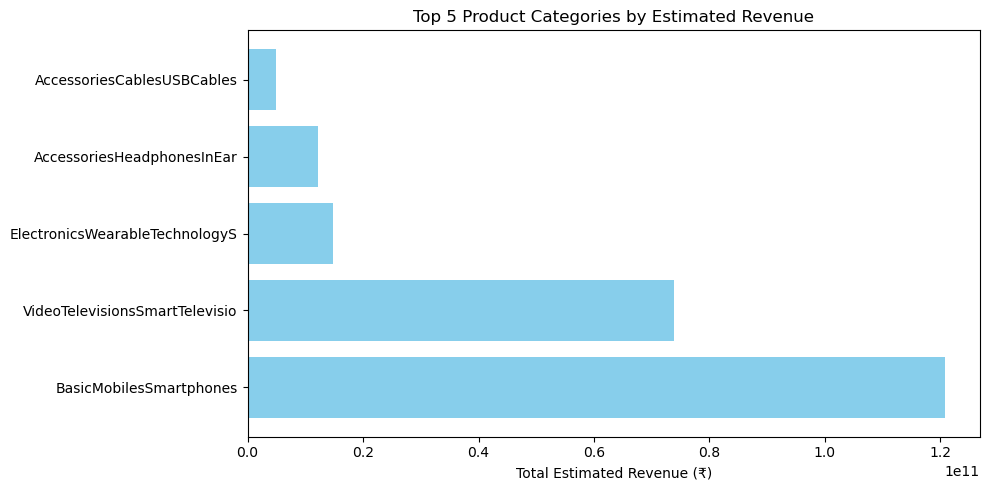

In [125]:
top_categories = data.groupby('category')['revenue_score'].sum().reset_index().sort_values(by='revenue_score', ascending=False).head(5)
plt.figure(figsize=(10, 5))
plt.barh(top_categories['category'].str[:30], top_categories['revenue_score'], color='skyblue')
plt.xlabel('Total Estimated Revenue (₹)')
plt.title('Top 5 Product Categories by Estimated Revenue')
plt.tight_layout()
plt.show()

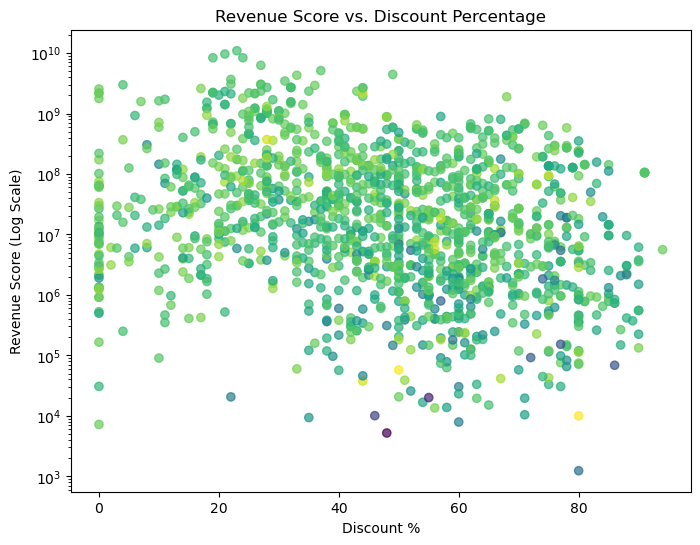

In [126]:
plt.figure(figsize=(8, 6))
plt.scatter(data['discount_percentage'], data['revenue_score'], c=data['rating'], cmap='viridis', alpha=0.7)
plt.yscale('log') # Use log scale since revenue numbers span wide ranges
plt.title('Revenue Score vs. Discount Percentage')
plt.xlabel('Discount %')
plt.ylabel('Revenue Score (Log Scale)')
plt.show()

In [127]:
data.to_csv('data.csv', index=False)

In [128]:
data.columns

Index(['product_name', 'category', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'about_product',
       'review_title', 'review_content', 'estimated_demand', 'revenue_score',
       'profit_margin_given', 'profit', 'sales', 'final_category',
       'main_category', 'sentiment'],
      dtype='object')

In [129]:
# big colors 
BG_COLOR = "#F8F9FA"       # Light gray background
CARD_BG = "#FFFFFF"        # Clean white for cards
TEXT_COLOR = "#2B2D42"     # Dark slate for text
ACCENT_COLOR = "#1D3557"   # Deep professional navy
GRID_COLOR = "#EAEAEA"

In [130]:
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

In [131]:
app.layout = dbc.Container(fluid=True, style={"backgroundColor": BG_COLOR, "padding": "20px", "minHeight": "100vh"}, children=[
    dbc.Row([
        
        # LEFT COLUMN: Hero Section / Sidebar (Mimicking the "King Kohli" visual)
        dbc.Col(md=3, className="p-4 rounded-3 d-flex flex-column justify-content-between", 
                style={
                    "background": f"linear-gradient(135deg, {ACCENT_COLOR} 0%, #457B9D 100%)", 
                    "color": "white", 
                    "boxShadow": "0 4px 15px rgba(0,0,0,0.1)",
                    "minHeight": "85vh"
                }, children=[
            html.Div([
                html.H1("AMAZON", style={"fontWeight": "900", "letterSpacing": "2px", "fontSize": "2.5rem"}),
                html.H3("SALES ENGINE", style={"fontWeight": "300", "opacity": "0.8", "fontSize": "1.2rem"}),
                html.Hr(style={"borderColor": "rgba(255,255,255,0.2)"}),
                html.P("Executive Analytics & Performance Insights Portfolio.", style={"fontSize": "0.9rem", "opacity": "0.7"}),
            ]),
                ]),
            # Interactive Filters inside the Hero panel
            html.Div([
                html.Label("Select Main Category", style={"fontWeight": "bold", "marginBottom": "5px"}),
                dcc.Dropdown(
                    id='category-dropdown',
                    options=[{'label': i, 'value': i} for i in data['main_category'].unique()],
                    value=data['main_category'].unique()[0],
                    clearable=False,
                    style={"color": "#000", "marginBottom": "20px"}
                ),
               
            
            html.Div([
                html.Small("Designed by Portfolio Client Delivery", style={"opacity": "0.5"})
            ])
        ]),
        
        # RIGHT COLUMN: The Data Dashboard Visuals
        dbc.Col(md=9, className="ps-4", children=[
            
            # Row 1: Professional KPI Cards
            dbc.Row(className="mb-4", children=[
                dbc.Col(md=3, children=[
                    html.Div(className="p-3 text-center rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Total Revenue", style={"color": "gray", "fontSize": "0.85rem"}),
                        html.H3(id="kpi-revenue", style={"color": ACCENT_COLOR, "fontWeight": "bold"})
                    ])
                ]),
                dbc.Col(md=3, children=[
                    html.Div(className="p-3 text-center rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Total Profit", style={"color": "gray", "fontSize": "0.85rem"}),
                        html.H3(id="kpi-profit", style={"color": "#2A9D8F", "fontWeight": "bold"})
                    ])
                ]),
                dbc.Col(md=3, children=[
                    html.Div(className="p-3 text-center rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Avg Customer Rating", style={"color": "gray", "fontSize": "0.85rem"}),
                        html.H3(id="kpi-rating", style={"color": ACCENT_COLOR, "fontWeight": "bold"})
                    ])
                ]),
                dbc.Col(md=3, children=[
                    html.Div(className="p-3 text-center rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Avg Discount Given", style={"color": "gray", "fontSize": "0.85rem"}),
                        html.H3(id="kpi-discount", style={"color": "#E63946", "fontWeight": "bold"})
                    ])
                ]),
            ]),
            
            # Row 2: Charts (Muted Bar chart + Donut Sentiment Chart)
            dbc.Row(className="mb-4", children=[
                dbc.Col(md=7, children=[
                    html.Div(className="p-3 rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Sales & Profit Margins By Category", style={"fontWeight": "bold", "color": TEXT_COLOR}),
                        dcc.Graph(id='bar-sales-profit', config={'displayModeBar': False})
                    ])
                ]),
                dbc.Col(md=5, children=[
                    html.Div(className="p-3 rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Review Sentiment Distribution", style={"fontWeight": "bold", "color": TEXT_COLOR}),
                        dcc.Graph(id='pie-sentiment', config={'displayModeBar': False})
                    ])
                ]),
            ]),
            
            # Row 3: Deep-Dive Relationship Scatter Chart
            dbc.Row(children=[
                dbc.Col(md=12, children=[
                    html.Div(className="p-3 rounded-3 shadow-sm", style={"backgroundColor": CARD_BG}, children=[
                        html.H6("Rating vs. Engagement Score (Size = Revenue)", style={"fontWeight": "bold", "color": TEXT_COLOR}),
                        dcc.Graph(id='scatter-deep-dive', config={'displayModeBar': False})
                    ])
                ])
            ])
            
        ])
    ])
])

In [132]:
@app.callback(
    [Output('kpi-revenue', 'children'),
     Output('kpi-profit', 'children'),
     Output('kpi-rating', 'children'),
     Output('kpi-discount', 'children'),
     Output('bar-sales-profit', 'figure'),
     Output('pie-sentiment', 'figure'),
     Output('scatter-deep-dive', 'figure')],
    [Input('category-dropdown', 'value'),
     Input('year-slider', 'value')]
)
def update_dashboard(selected_category, selected_year):
    # Filter Data dynamically
    filtered_df = df[df['year'] == selected_year]
    cat_df = filtered_df[filtered_df['main_category'] == selected_category]
    
    # 1. Compute KPIs
    total_rev = f"${filtered_df['sales'].sum()/1e3:.1f}K"
    total_prof = f"${filtered_df['profit'].sum()/1e3:.1f}K"
    avg_rating = f"{cat_df['rating'].mean():.2f} ★"
    avg_disc = f"{cat_df['discount_percentage'].mean()*100:.1f}%"
    
    # Template to remove white background outlines (Secret to professional Plotly looks)
    clean_layout = dict(
        plot_bgcolor=CARD_BG,
        paper_bgcolor=CARD_BG,
        font=dict(color=TEXT_COLOR, family="Segoe UI, sans-serif"),
        margin=dict(l=40, r=20, t=20, b=40),
        xaxis=dict(showgrid=False),
        yaxis=dict(gridcolor=GRID_COLOR)
    )

    # 2. Bar Chart: Sales vs Profit
    fig_bar = px.bar(
        filtered_df.groupby('main_category')[['sales', 'profit']].sum().reset_index(),
        x='main_category', y='sales',
        color_discrete_sequence=[ACCENT_COLOR]
    )
    fig_bar.update_layout(clean_layout)
    
    # 3. Donut Chart: Sentiment
    sentiment_counts = cat_df['sentiment'].value_counts().reset_index()
    fig_pie = px.pie(
        sentiment_counts, names='sentiment', values='count',
        hole=0.6,
        color_discrete_sequence=['#2A9D8F', '#E9C46A', '#E63946'] # Green, Yellow, Red tones
    )
    fig_pie.update_layout(clean_layout, showlegend=True, margin=dict(l=20, r=20, t=20, b=20))
    
    # 4. Scatter Plot: Rating vs Rating Count (Engagement)
    fig_scatter = px.scatter(
        cat_df, x='rating', y='rating_count', size='sales',
        color_discrete_sequence=['#457B9D'], opacity=0.7
    )
    fig_scatter.update_layout(clean_layout)
    
    return total_rev, total_prof, avg_rating, avg_disc, fig_bar, fig_pie, fig_scatter

In [133]:
if __name__ == '__main__':
    app.run_server(debug=True)

ObsoleteAttributeException: app.run_server has been replaced by app.run